In [1]:
import pandas as pd
!wget https://raw.githubusercontent.com/trailorr/NLP-Date-a-Base/refs/heads/main/okcupid_profiles-1.csv
!wget https://raw.githubusercontent.com/trailorr/NLP-Date-a-Base/refs/heads/main/okcupid_profiles-2.csv


filepaths = ['okcupid_profiles-1.csv', 'okcupid_profiles-2.csv']
profiles = pd.concat(map(pd.read_csv, filepaths), ignore_index=True)

#print(profiles.head(10))

--2025-04-25 13:05:18--  https://raw.githubusercontent.com/trailorr/NLP-Date-a-Base/refs/heads/main/okcupid_profiles-1.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 74288225 (71M) [text/plain]
Saving to: ‘okcupid_profiles-1.csv’

okcupid_profiles-1. 100%[===================>]  70.85M  85.5MB/s    in 0.8s    

2025-04-25 13:05:20 (85.5 MB/s) - ‘okcupid_profiles-1.csv’ saved [74288225/74288225]

--2025-04-25 13:05:20--  https://raw.githubusercontent.com/trailorr/NLP-Date-a-Base/refs/heads/main/okcupid_profiles-2.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent

<ipython-input-1-0913a1145bce>:7: DtypeWarning: Columns (0,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133) have mixed types. Specify dtype option on import or set low_memory=False.
  profiles = pd.concat(map(pd.read_csv, filepaths), ignore_index=True)


In [2]:
!pip install spacy nltk pandas scikit-learn matplotlib seaborn
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 96.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


## Prep data

In [3]:
from sklearn.model_selection import train_test_split

# divide dataset into 80% testing, 20% training
train_data, test_data = train_test_split(profiles, test_size=0.2, random_state=42)


In [4]:
## Grace: get desired columns from training data (will need to do later with testing data)
age_column = train_data['age']
essay_columns = ['essay0', 'essay1', 'essay2', 'essay3', 'essay4', 'essay5', 'essay6']

In [5]:
range18to24 = []
range25to34 = []
range35to44 = []
range45to54 = []
range55to64 = []

# clean data to only include ints

for age in age_column:
  try:
    age = int(age)
    if age >= 18 and age <= 24:
      range18to24.append(age)
    elif age >= 25 and age <= 34:
      range25to34.append(age)
    elif age >= 35 and age <= 44:
      range35to44.append(age)
    elif age >= 45 and age <= 54:
      range45to54.append(age)
    elif age >= 55 and age <= 64:
      range55to64.append(age)

  except ValueError:
    pass

#print(len(range18to24))
#print(len(range25to34))
#print(len(range35to44))
#print(len(range45to54))
#print(len(range55to64))

In [6]:
# Grace: choose 2000 random entries for each age range (except for 55 to 64)

group_1 = []
group_2 = []
group_3 = []
group_4 = []
group_5 = []

for age in age_column:
  try:
    age = int(age)
    if age >= 18 and age <= 24:
      range18to24.append(age)
    elif age >= 25 and age <= 34:
      range25to34.append(age)
    elif age >= 35 and age <= 44:
      range35to44.append(age)
    elif age >= 45 and age <= 54:
      range45to54.append(age)
    elif age >= 55 and age <= 64:
      range55to64.append(age)

  except ValueError:
    pass

In [7]:
# Combining all the short answer responses to one string
import string
import re
import nltk
from nltk.corpus import stopwords
from nltk.tag import PerceptronTagger

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')  #for pos tagging
nltk.download('tagsets')

def clean_text(text):
    if isinstance(text, str):
        text = text.lower()
        text = re.sub(r'[^\w\s]', '', text)
        text = re.sub(r'\d+', '', text)
        text = re.sub(r'\s+', ' ', text).strip()
        return text
    return ''

# Create combined responses and clean them
train_data['combined_responses'] = train_data[essay_columns].fillna('').agg(' '.join, axis=1)
train_data['cleaned_responses'] = train_data['combined_responses'].apply(clean_text)

test_data['combined_responses'] = test_data[essay_columns].fillna('').agg(' '.join, axis=1)
test_data['cleaned_responses'] = test_data['combined_responses'].apply(clean_text)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package tagsets to /root/nltk_data...
[nltk_data]   Unzipping help/tagsets.zip.


## Baselines

In [8]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, accuracy_score

# Create age groups
def assign_age_group(age):
    try:
        age = int(age)
        if 18 <= age <= 24: return 0
        elif 25 <= age <= 34: return 1
        elif 35 <= age <= 44: return 2
        elif 45 <= age <= 54: return 3
        elif 55 <= age <= 64: return 4
        else: return -1
    except:
        return -1

# Apply to train and test data
train_data['age_group'] = train_data['age'].apply(assign_age_group)
train_data = train_data[train_data['age_group'] != -1]

test_data['age_group'] = test_data['age'].apply(assign_age_group)
test_data = test_data[test_data['age_group'] != -1]

# Create balanced datasets
balanced_train = pd.DataFrame()
balanced_test = pd.DataFrame()

for age_group in range(5):
    train_group = train_data[train_data['age_group'] == age_group]
    if len(train_group) > 2000:
        train_group = train_group.sample(n=2000, random_state=42)
    balanced_train = pd.concat([balanced_train, train_group])

    test_group = test_data[test_data['age_group'] == age_group]
    if len(test_group) > 500:
        test_group = test_group.sample(n=500, random_state=42)
    balanced_test = pd.concat([balanced_test, test_group])

# Get X and y
X_train = balanced_train['cleaned_responses']
y_train = balanced_train['age_group']
X_test = balanced_test['cleaned_responses']
y_test = balanced_test['age_group']

print(f"Train set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples\n")
print("Age group distribution in training set:")
print(y_train.value_counts())
print()

# Random baseline
random_classifier = DummyClassifier(strategy='uniform', random_state=42)
random_classifier.fit(X_train.str.len().values.reshape(-1, 1), y_train)
random_predictions = random_classifier.predict(X_test.str.len().values.reshape(-1, 1))
random_accuracy = accuracy_score(y_test, random_predictions)
print(f"Random baseline accuracy: {random_accuracy:.4f}")

# Most frequent class baseline
majority_classifier = DummyClassifier(strategy='most_frequent', random_state=42)
majority_classifier.fit(X_train.str.len().values.reshape(-1, 1), y_train)
majority_predictions = majority_classifier.predict(X_test.str.len().values.reshape(-1, 1))
majority_accuracy = accuracy_score(y_test, majority_predictions)
print(f"Majority class baseline accuracy: {majority_accuracy:.4f}")

# Stratified baseline
stratified_classifier = DummyClassifier(strategy='stratified', random_state=42)
stratified_classifier.fit(X_train.str.len().values.reshape(-1, 1), y_train)
stratified_predictions = stratified_classifier.predict(X_test.str.len().values.reshape(-1, 1))
stratified_accuracy = accuracy_score(y_test, stratified_predictions)
print(f"Stratified baseline accuracy: {stratified_accuracy:.4f}")

# Store baseline results for later comparison
baseline_results = {
    'Random': random_accuracy,
    'Majority': majority_accuracy,
    'Stratified': stratified_accuracy
}

Train set: 9578 samples
Test set: 2421 samples

Age group distribution in training set:
age_group
0    2000
1    2000
2    2000
3    2000
4    1578
Name: count, dtype: int64

Random baseline accuracy: 0.2102
Majority class baseline accuracy: 0.2065
Stratified baseline accuracy: 0.2111


## Bag of Words with POS

In [9]:
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [10]:
def tokenize(essay):
  tokens = nltk.word_tokenize(essay)
  tags = nltk.pos_tag(tokens)
  pos = ([tag for word, tag in tags])
  return tokens, tags, pos

tokenized_test = []
tagged_test = []
pos_only_test = []

tokenized_train = []
tagged_train = []
pos_only_train = []

for text in X_train: #preprocessing training data
  token_train, tag_train, pos_train = tokenize(text)
  tokenized_train.append(token_train)
  tagged_train.append(tag_train)
  pos_only_train.append(pos_train)

for text in X_test: #preprocessing testing data
  token_test, tag_test, pos_test = tokenize(text)
  tokenized_test.append(token_test)
  tagged_test.append(tag_test)
  pos_only_test.append(pos_test)

In [11]:
pos_count_train = {}
pos_count_test = {}

def freq_pos(pos, pos_count): #getting frequencies of pos in each essay
  for essay_tags in pos:
    for word, tag in essay_tags:
      if tag not in pos_count:
        pos_count[tag] = 1
      else:
        pos_count[tag] += 1
  fdist = nltk.FreqDist(pos_count)
  pos_common = fdist.most_common(10)
  return pos_common

freq_train = freq_pos(tagged_train, pos_count_train)
freq_test = freq_pos(tagged_test, pos_count_test)

In [14]:
import numpy as np
Xbow_train = []
Xbow_test = []

def bow(pos_list, pos_count, Xbow_list): #creating bag of words vectors
  for essay in pos_list:
    #print("Essay", essay)
    pos_bow = []
    for part in pos_count:
      if part[0] in essay:
        pos_bow.append(1)
      else:
        pos_bow.append(0)
    #print("POS:", pos_bow)
    Xbow_list.append(pos_bow)
  return np.asarray(Xbow_list)

bow_train = bow(pos_only_train, freq_train, Xbow_train)
#print("BoW", freq_train)
bow_test = bow(pos_only_test, freq_test, Xbow_test)


In [15]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_validate
from sklearn import metrics
gnb = GaussianNB()

gnb.fit(bow_train, y_train)

y_pred = gnb.predict(bow_test)

bow_accuracy = accuracy_score(y_test, y_pred)

print(f"BoW with PoS Tagging Accuracy: {bow_accuracy:.4f}\n")
print(classification_report(y_test, y_pred))

BoW with PoS Tagging Accuracy: 0.2082

              precision    recall  f1-score   support

           0       0.25      0.14      0.18       500
           1       0.20      0.86      0.33       500
           2       0.00      0.00      0.00       500
           3       0.11      0.00      0.00       500
           4       0.00      0.00      0.00       421

    accuracy                           0.21      2421
   macro avg       0.11      0.20      0.10      2421
weighted avg       0.12      0.21      0.11      2421



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## TF-IDF

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier

# Using TF-IDF with n-grams...
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=5,
    ngram_range=(1, 2)  # Unigrams and bigrams to improve accuracy
)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# Train and evaluate model
tfidf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
tfidf_model.fit(X_train_tfidf, y_train)
tfidf_predictions = tfidf_model.predict(X_test_tfidf)

tfidf_accuracy = accuracy_score(y_test, tfidf_predictions)
print(f"TF-IDF Accuracy: {tfidf_accuracy:.4f}")
print(classification_report(y_test, tfidf_predictions))

TF-IDF Accuracy: 0.4036
              precision    recall  f1-score   support

           0       0.50      0.67      0.57       500
           1       0.37      0.32      0.34       500
           2       0.33      0.25      0.29       500
           3       0.33      0.48      0.39       500
           4       0.52      0.28      0.37       421

    accuracy                           0.40      2421
   macro avg       0.41      0.40      0.39      2421
weighted avg       0.41      0.40      0.39      2421



## Mistral (zero-shot) baseline for exact age prediction

In [17]:
! pip install mistralai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 301.5/301.5 kB 7.4 MB/s eta 0:00:00


In [18]:
## Prepping Mistral to be used
from mistralai import Mistral

client = Mistral(api_key="KIBsiu033AFSwAHBXveuNDfuxv511dmm")

MODEL = "mistral-large-latest"

In [19]:
mistral_sample_size = 20
mistral_test_data = X_test.sample(n=mistral_sample_size, random_state=42)
mistral_test_labels = y_test[mistral_test_data.index]

In [20]:
import time

mistral_pred = []

def create_mistral_prompt(text):
    prompt = f"""You are able to determine a person's age group based on their writing style.

Based on the following text, which age group (18-24, 25-34, 35-44, 45-54, or 55-64) does the author most likely belong to?

TEXT: {text[:500]}

Please analyze the writing style, references, life experiences, and concerns mentioned. Answer with JUST the age range (18-24, 25-34, 35-44, 45-54, or 55-64) and nothing else.
"""
    return prompt

for i, text in enumerate(mistral_test_data):
    if not text.strip():
        mistral_pred.append(1)  # Default to most common group
        continue

    prompt = create_mistral_prompt(text)

    completion = client.chat.complete(
            model=MODEL,
            messages=[{"role": "user", "content": prompt}]
    )

    prediction = completion.choices[0].message.content.strip()

    # Map text responses to age groups
    age_group_map = {
            "18-24": 0, "25-34": 1, "35-44": 2, "45-54": 3, "55-64": 4
    }

    # Append only once per sample
    found_match = False  # Flag to track if a match is found
    for age_range, group_id in age_group_map.items():
        if age_range in prediction:
            mistral_pred.append(group_id)
            found_match = True
            break  # Exit the loop once a match is found

    # If no match is found, append the default value
    if not found_match:
        mistral_pred.append(1)

    time.sleep(5)  # Rate limiting

mistral_accuracy = accuracy_score(mistral_test_labels, mistral_pred)
print(f"Mistral Accuracy: {mistral_accuracy:.4f}\n")
print(classification_report(mistral_test_labels, mistral_pred))

Mistral Accuracy: 0.4000

              precision    recall  f1-score   support

           0       1.00      0.43      0.60         7
           1       0.20      0.50      0.29         2
           2       0.33      0.60      0.43         5
           3       0.33      0.25      0.29         4
           4       0.00      0.00      0.00         2

    accuracy                           0.40        20
   macro avg       0.37      0.36      0.32        20
weighted avg       0.52      0.40      0.40        20



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Mistral (few-shot)

In [21]:
mistral_few_pred = []

def create_mistral_few_prompt(text):
    prompt = f"""You are able to determine a person's age group based on their writing style.

Based on the following text, which age group (18-24, 25-34, 35-44, 45-54, or 55-64) does the author most likely belong to?

TEXT: {text[:500]}

Here are some examples:
Age 24: oh goodness. at the moment i have 4 jobs, so it'd be nice to find one i could settle into.
Age 39: i'm usually pretty exhausted by friday. so usually it's a whole lot of nothin'!
Please analyze the writing style, references, life experiences, and concerns mentioned. Answer with JUST the age range (18-24, 25-34, 35-44, 45-54, or 55-64) and nothing else.
"""
    return prompt

for i, text in enumerate(mistral_test_data):
    if not text.strip():
        mistral_few_pred.append(1)  # Default to most common group
        continue

    prompt = create_mistral_few_prompt(text)

    completion = client.chat.complete(
            model=MODEL,
            messages=[{"role": "user", "content": prompt}]
    )

    prediction = completion.choices[0].message.content.strip()

    # Map text responses to age groups
    age_group_map = {
            "18-24": 0, "25-34": 1, "35-44": 2, "45-54": 3, "55-64": 4
    }

    # Append only once per sample
    found_match = False  # Flag to track if a match is found
    for age_range, group_id in age_group_map.items():
        if age_range in prediction:
            # Appending to mistral_few_pred instead of mistral_pred
            mistral_few_pred.append(group_id)
            found_match = True
            break  # Exit the loop once a match is found

    # If no match is found, append the default value
    if not found_match:
        mistral_few_pred.append(1)

    time.sleep(5)  # Rate limiting

mistral_few_accuracy = accuracy_score(mistral_test_labels, mistral_few_pred)
print(f"Mistral Accuracy: {mistral_few_accuracy:.4f}\n")
print(classification_report(mistral_test_labels, mistral_few_pred))

Mistral Accuracy: 0.5000

              precision    recall  f1-score   support

           0       1.00      0.57      0.73         7
           1       0.25      0.50      0.33         2
           2       0.44      0.80      0.57         5
           3       0.33      0.25      0.29         4
           4       0.00      0.00      0.00         2

    accuracy                           0.50        20
   macro avg       0.41      0.42      0.38        20
weighted avg       0.55      0.50      0.49        20



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Comparing the models


Model Comparison:
                 Model  Accuracy
0               Random  0.210244
1             Majority  0.206526
2           Stratified  0.211070
3         BoW with POS  0.208178
4               TF-IDF  0.403552
5  Mistral (zero-shot)  0.400000
6   Mistral (few-shot)  0.500000


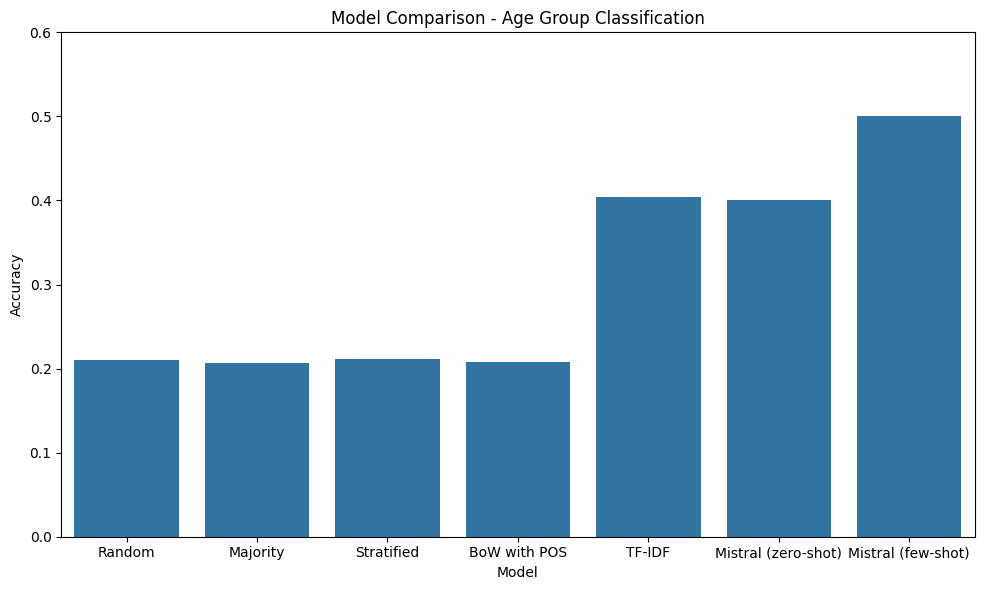

In [23]:
# Compare all models
import matplotlib.pyplot as plt
import seaborn as sns

# Create comparison DataFrame
results = pd.DataFrame({
    'Model': ['Random', 'Majority', 'Stratified', 'BoW with POS', 'TF-IDF', 'Mistral (zero-shot)', 'Mistral (few-shot)'],
    'Accuracy': [baseline_results['Random'], baseline_results['Majority'],
                 baseline_results['Stratified'], bow_accuracy,
                 tfidf_accuracy, mistral_accuracy, mistral_few_accuracy]
})

# Print comparison
print("\nModel Comparison:")
print(results)

# Create bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=results)
plt.title('Model Comparison - Age Group Classification')
plt.ylim(0, max(results['Accuracy']) * 1.2)
plt.tight_layout()
plt.show()